# Putting it All Together: A Hands-On WRF Case Study

Ready to see HPC in action? This notebook demonstrates a practical 6-hour forecast using the Weather Research and Forecasting (WRF) model. Throughout this guide, we will apply everything we have covered so far (from installing packages with Spack and managing environments with LMOD/Modules, to submitting and monitoring Slurm jobs).

As illustrated in the diagram below, a standard WRF workflow consists of multiple complex stages. To streamline this exercise, we have provided the required pre-processing files, allowing you to focus exclusively on the simulation phase (`wrf`).

![wrf-execution-workflow](https://www2.mmm.ucar.edu/wrf/OnLineTutorial/images/flow.png)

Want to see the whole process? Follow the [WRF Execution: Full Example](../complete/main.ipynb) for a comprehensive, step-by-step guide.

## Case Study: Hurricane Matthew

For this simulation, we are using the [Hurricane Matthew](https://www.nhc.noaa.gov/data/tcr/AL142016_Matthew.pdf) test case provided by [WRF-ARW](https://www2.mmm.ucar.edu/wrf/OnLineTutorial/CASES/SingleDomain/index.php). This scenario simulates the development of [Hurricane Matthew](https://www.nhc.noaa.gov/data/tcr/AL142016_Matthew.pdf), a powerful and destructive Category 5 cyclone from 2016.

![matthew](https://www2.mmm.ucar.edu/wrf/OnLineTutorial/CASES/SingleDomain/matthew.jpg)

The full simulation covers a 48-hour period, from 00:00 UTC on October 6 to 00:00 UTC on October 8, 2016. The first 18 hours of the model run have already been processed; **our task is to perform a restart and continue the simulation for the next 6 hours**.


## 1. Environment Setup

First, we need to configure our Python environment to execute commands directly from this notebook. We will create a virtual environment to manage dependencies and install the necessary packages.

```bash
# Create a virtual environment (recommended)
module load python/3.12
python3 -m venv wrf-venv
source wrf-venv/bin/activate

# Install dependencies
pip install -r requirements.txt
```

**Installing `wrf-python`**

An additional requirement for this tutorial is the `wrf-python` package. Although it is available on PyPI, the PyPI version is currently outdated and may not be compatible with recent Python releases. For this reason, we will install the latest stable version directly from the official GitHub source:

```
# Download and install wrf-python from source
wget https://codeload.github.com/NCAR/wrf-python/tar.gz/refs/tags/v1.4.2
tar -xvf v1.4.2
cd wrf-python-1.4.2
pip install .
```

**Note:** Once the installation is complete, ensure you change the **Selected Kernel** of this notebook to `wrf-venv `to use the newly installed environment.

## 2. Download Preprocessed Input Data

Before executing the simulation, we must download the preprocessed input data archive `input.zip`. This file contains an `input/` directory with the following components:

- `namelist.input`: the namelist file for the WRF model.
- `wrfbdy_d01`: the boundary conditions file for the WRF model (output of `real` step).
- `wrfinput_d01`: the initial conditions file for the WRF model (output of `real` step).
- `wrfrst_d01_2016-10-07_00:00:00`: the WRF restart file of a previous run.
- `wrfout_d01_2016-10-07_00:00:00`: the WRF output file of a previous run.

This package contains the necessary files to bypass the initial WPS (Preprocessing) and `real.exe` stages, allowing you to focus strictly on the model execution and restart logic.

Run the following cell to download and extract the data:

In [1]:
%%script bash
#!/bin/bash

# Download input data if it doesn't already exist
if [ ! -f input.zip ]; then
    wget --no-check-certificate -r 'https://drive.usercontent.google.com/download?export=download&id=17K6Op9fz4qOOfB6PoWTWY_Kwni_i6wGQ&confirm=t' -O input.zip
fi

# Unzip the input data
mkdir input
unzip -o input.zip -d input

mkdir: cannot create directory ‘input’: File exists


Archive:  input.zip
  inflating: input/namelist.input    
  inflating: input/wrfbdy_d01        
  inflating: input/wrfinput_d01      
  inflating: input/wrfout_d01_2016-10-07_00:00:00  
  inflating: input/wrfrst_d01_2016-10-07_00:00:00  


After unzipping, you should see the `input/` directory containing your `namelist.input`, boundary files (`wrfbdy_d01`), and the restart files required for this exercise

## 3. Launching the WRF Simulation

To manage our simulation directly from this notebook, we will use the `slurm-magic` extension. This allows us to submit and monitor Slurm jobs using a simple `%%sbatch` cell magic. 

First, load the extension into your notebook environment:

In [2]:
%load_ext slurm_magic

Once the extension is loaded, we can create our Slurm batch script. This script executes `wrf.exe` using **4 CPU cores** to generate the final 6-hour forecast (leading up to October 7 at 09:00 UTC). 

We have reserved **1GB of RAM per core**, totaling **4GB** for the entire simulation. On a typical consumer-grade computer, this simulation should complete in approximately **5 minutes**. 

> **Tip:** Adding more cores does not always result in faster computation. In HPC, "Parallel Efficiency" eventually plateaus or drops due to the communication overhead between cores. Feel free to experiment with the `--ntasks` value to observe how it affects performance.

In [3]:
%%sbatch
#!/bin/bash
#SBATCH --job-name=wrf-simulation
#SBATCH --ntasks=4
#SBATCH --mem-per-cpu=1G
#SBATCH --output=wrf_simulation.out
#SBATCH --error=wrf_simulation.err

# Set ENV variables
CUR_DIR=$(pwd)            
WRF_RUN=${CUR_DIR}/rundir
WRF_INP=${CUR_DIR}/input
SRUN_FLAGS="-n $SLURM_NTASKS"
# Clear previous outputs and create new one
rm -rf ${WRF_RUN} && mkdir -p ${WRF_RUN}

# Load modules
module load spack 
module load wrf

# Move to WRF_RUN directory and link control files for wrf.exe
cd ${WRF_RUN}
ln -sfn ${WRF_HOME}/run/* .	
cp ${WRF_HOME}/configure.wrf .
ln -sfn ${WRF_INP}/* .

# Run
srun $SRUN_FLAGS ./wrf.exe

'Submitted batch job 76\n'

### 3.1 Monitoring Job Progress

**Checking Slurm Queue**

Now that you have submitted your job, you must wait for it to finish. You can monitor its status in the Slurm queue by executing the following command:

In [4]:
%squeue --me

,JOBID,PARTITION,NAME,USER,ST,TIME,NODES,NODELIST(REASON)
0,76,split,wrf-simu,roosevel,R,0:04,1,servbsbhpc005


Once your Job ID disappears from the table, the simulation is complete, and you are ready to move to the next step.

**Checking the Logs**

While the job is running (or after it finishes), you can verify the model's progress in real-time by checking the WRF output log:

In [7]:
%%script bash
tail rundir/rsl.out.0000

Timing for main: time 2016-10-07_08:42:30 on domain   1:    0.56734 elapsed seconds
TimingTiming for main: time 2016-10-07_08:47:30 on domain   1:    2.92716 elapsed seTiming for main: time 2016-10-07_08:47:30 on domain   1:    2.92747 elapsed seconds
Timing for main: time 2016-10-07_08:50:00 on domain   1:    0.56877 elapsed seconds
Timing for main: time 2016-10-07_08:52:30 on domain   1:    0.56966 elapsed seconds
Timing for main: time 2016-10-07_08:55:00 on domain   1:    0.56859 elapsed seconds
Timing for main: time 2016-10-07_08:57:30 on domain   1:    0.55575 elapsed seconds
Timing for main: time 2016-10-07_09:00:00 on domain   1:    0.55881 elapsed seconds
open_hist_w : error opening wrfout_d01_2016-10-07_09:00:00 for writing. -1021
Timing for Writing wrfout_d01_2016-10-07_09:00:00 for domain        1:    0.02987 elapsed seconds
d01 2016-10-07_09:00:00 wrf: SUCCESS COMPLETE WRF


If you see the message **`SUCCESS COMPLETE WRF`** at the end of your log file, it means your simulation has ended successfully, and you are ready to move to the next step.

## 4. Visualizing the Results

If you check your `rundir/`, you will notice that the simulation has generated three new output files following the format `wrfout_d01_2016-10-07_**:00:00`. However, these are NetCDF files, which are not directly readable or easy to interpret without specialized tools.

To analyze the data, we need a package capable of parsing these complex multidimensional datasets and generating meaningful visualizations. We will use **`wrf-python`**, a library specifically designed to handle WRF output and calculate common meteorological diagnostics.

**Why use `wrf-python`?**

While standard NetCDF libraries can open these files, `wrf-python` understands the specific staggered grid and metadata used by WRF. It allows us to easily extract variables like:
* **Sea Level Pressure (SLP)**
* **Wind Speed and Direction**
* **Reflectivity (Simulated Radar)**
* **Temperature and Humidity profiles**

In the following cells, we will use `wrf-python` alongside `matplotlib` and `cartopy` to map the final hours of Hurricane Matthew's trajectory.



### Animating the Storm Trajectory

To better understand the evolution of Hurricane Matthew, we will create an animated GIF of the **Sea Level Pressure (SLP)**. Static plots are useful, but animation allows us to visualize the atmospheric dynamics and the movement of the storm's eye over time.

The following function, `animate_slp`, combines the historical 18-hour data with our newly generated 6-hour forecast. It performs several key tasks:
* **Data Normalization:** It calculates a consistent color scale across all time steps so the pressure changes are comparable.
* **Spatial Smoothing:** It applies a 2D smoothing pass to the SLP data to reduce numerical noise and highlight the primary low-pressure system.
* **Geospatial Mapping:** It uses `cartopy` to project the data onto a realistic map with coastlines.

Run the cell below to generate `slp.gif` and witness the full 24-hour progression of the hurricane.

Skipping rundir/wrfout_d01_2016-10-07_06:00:00: [Errno -101] NetCDF: HDF error: 'rundir/wrfout_d01_2016-10-07_06:00:00'
Skipping rundir/wrfout_d01_2016-10-07_09:00:00: [Errno -101] NetCDF: HDF error: 'rundir/wrfout_d01_2016-10-07_09:00:00'


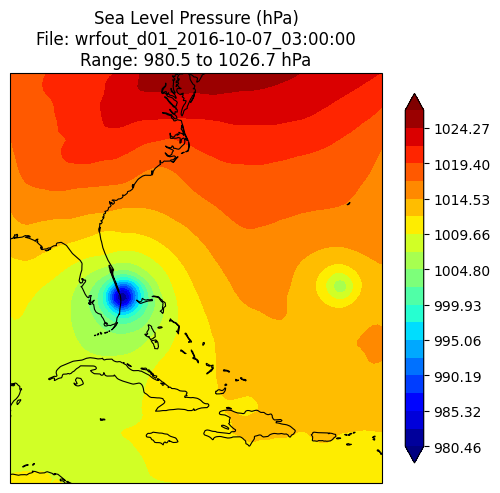

In [8]:
from matplotlib.animation import FuncAnimation
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import cartopy.crs as crs
import numpy as np

from wrf import (
    getvar, smooth2d, latlon_coords, get_cartopy, to_np,
)


def animate_slp(output_files, base_dir="", output_filename="slp.gif", smooth_passes=3, cenweight=4, cmap="jet", interval=500):
    
    valid_files = [] # Track which files actually work
    
    def get_color_scale(files, base_dir=""):
        vmin, vmax = float("inf"), float("-inf")
        found_files = []
        for f in files:
            path = base_dir + f
            try:
                ncfile = Dataset(path)
                try:
                    slp = getvar(ncfile, "slp")
                    smooth_slp = smooth2d(slp, smooth_passes, cenweight=cenweight)
                    vmin = min(vmin, float(smooth_slp.min()))
                    vmax = max(vmax, float(smooth_slp.max()))
                    found_files.append(f) # Only add if reading succeeded
                finally:
                    ncfile.close()
            except OSError as e:
                print(f"Skipping {f}: {e}")
                continue 
        return vmin, vmax, found_files

    # 1. Identify valid files and set the global scale
    vmin, vmax, valid_files = get_color_scale(output_files, base_dir)
    
    if not valid_files:
        print("No valid files found to animate.")
        return

    clevels = np.linspace(vmin, vmax, 20)
    fig = plt.figure(figsize=(6, 6))

    def update(frame):
        fig.clear()
        # Use the valid_files list instead of the original output_files
        current_file = valid_files[frame]
        
        try:
            ncfile = Dataset(base_dir + current_file)
            try:
                slp = getvar(ncfile, "slp")
                smooth_slp = smooth2d(slp, smooth_passes, cenweight=cenweight)
                lats, lons = latlon_coords(slp)
                cart_proj = get_cartopy(slp)
                
                ax = plt.axes(projection=cart_proj)
                ax.coastlines("50m", linewidth=0.8)
                
                contourf = ax.contourf(
                    to_np(lons), to_np(lats), to_np(smooth_slp),
                    levels=clevels,
                    vmin=vmin,
                    vmax=vmax,
                    transform=crs.PlateCarree(),
                    cmap=plt.get_cmap(cmap),
                    extend="both"
                )

                plt.colorbar(contourf, ax=ax, shrink=0.8, pad=0.05, ticks=clevels[::2])
                fn = current_file.split('/')[-1]
                plt.title(f"Sea Level Pressure (hPa)\nFile: {fn}\nRange: {vmin:.1f} to {vmax:.1f} hPa")
            finally:
                ncfile.close()
        except Exception as e:
            print(f"Error during animation update on {current_file}: {e}")

    # Use len(valid_files) so the animation doesn't try to index missing data
    anim = FuncAnimation(fig, update, frames=len(valid_files), repeat=False, interval=interval)
    anim.save(output_filename, writer="pillow")

# List remains the same
output_files = [
    # Previously run 18-hour forecast
    "../complete-case/output/wrfout_d01_2016-10-06_09:00:00",
    "../complete-case/output/wrfout_d01_2016-10-06_12:00:00",
    "../complete-case/output/wrfout_d01_2016-10-06_15:00:00",
    "../complete-case/output/wrfout_d01_2016-10-06_18:00:00",
    "../complete-case/output/wrfout_d01_2016-10-06_21:00:00",
    "../complete-case/output/wrfout_d01_2016-10-07_00:00:00",
    # new 6-hour forecast
    "rundir/wrfout_d01_2016-10-07_03:00:00",
    "rundir/wrfout_d01_2016-10-07_06:00:00",
    "rundir/wrfout_d01_2016-10-07_09:00:00",
]

animate_slp(output_files, output_filename="slp.gif", interval=500)

![slp.gif](slp.gif)

### Beyond Sea Level Pressure

This animation is just the beginning. The `wrf-python` library is incredibly versatile, allowing you to calculate and visualize complex meteorological diagnostics like **Potential Vorticity**, **Simulated Radar Reflectivity**, and **Vertical Cross-sections**.

To dive deeper into advanced visualization techniques—such as multi-panel plotting, wind vector overlays, or 3D data extraction—explore the official resources:

* **[wrf-python Documentation](https://wrf-python.readthedocs.io/)**: For detailed API references and function logic.
* **[wrf-python Gallery & Examples](https://wrf-python.readthedocs.io/en/latest/plot.html)**: For ready-to-use scripts covering a wide range of weather variables.

**Congratulations on completing your first end-to-end HPC workflow with WRF!**